# Preprocessing

Builds the inflation panel and the three observed network matrices used by the final experiments. Earlier exploratory disaggregated-CPI and correlation-network work is omitted.

In [85]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "OECD").exists():
    raise FileNotFoundError("Run preprocessing.ipynb from the project root.")

COUNTRIES = [
    "PRT", "ESP", "NOR", "GRC", "SWE", "NLD", "DNK", "DEU",
    "CAN", "FIN", "LUX", "GBR", "USA", "CHE", "AUT", "IRL",
    "FRA", "ITA", "BEL", "POL", "HUN", "KOR", "ISR",
]
N = len(COUNTRIES)
SPLIT_DATE = pd.Timestamp("2016-01-01")

OECD_RAW = DATA_DIR / "OECD" / "OECD-raw-COICOP1999.csv"
GRAVITY_RAW = DATA_DIR / "CEPII" / "Gravity.csv"
COMTRADE_RAW = DATA_DIR / "Comtrade" / "comtrade-Top24-XandM-2010-2021.csv"

INFLATION_OUT = DATA_DIR / "OECD" / "inflation.csv"
W_GEO_OUT = DATA_DIR / "CEPII" / "W_geo.csv"
W_EX_OUT = DATA_DIR / "Comtrade" / "W_ex.csv"
W_IM_OUT = DATA_DIR / "Comtrade" / "W_im.csv"

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})


def verify_or_save(df, path, parse_dates=False):
    """Verify an existing final CSV exactly, or create it if absent."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        old = pd.read_csv(path, index_col=0, parse_dates=parse_dates)
        pd.testing.assert_index_equal(old.index, df.index, check_names=False)
        pd.testing.assert_index_equal(old.columns, df.columns, check_names=False)
        # np.testing.assert_array_equal(old.to_numpy(dtype=float), df.to_numpy(dtype=float))
        np.testing.assert_allclose(old.to_numpy(dtype=float), df.to_numpy(dtype=float), rtol=1e-13, atol=1e-14)
        print(f"verified existing {path}")
        return
    df.to_csv(path)
    print(f"saved {path}")

## Inflation panel

In [86]:
oecd = pd.read_csv(OECD_RAW)

oecd = oecd[
    (oecd["MEASURE"] == "CPI")
    & (oecd["UNIT_MEASURE"] == "IX")
    & (oecd["TRANSFORMATION"] == "_Z")
    & (oecd["METHODOLOGY"] == "N")
][["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]].copy()

oecd.columns = ["country", "date", "cpi"]
oecd["cpi"] = pd.to_numeric(oecd["cpi"], errors="coerce")

cpi = oecd.pivot(index="date", columns="country", values="cpi")
cpi.index = pd.to_datetime(cpi.index)

inflation = 100 * (np.log(cpi) - np.log(cpi.shift(12)))
inflation = inflation[COUNTRIES].loc["1991-01":"2024-06"]

expected_dates = pd.date_range("1991-01-01", "2024-06-01", freq="MS")
assert inflation.index.equals(expected_dates)
assert inflation.shape == (402, N)
assert np.isfinite(inflation.to_numpy()).all()
assert (inflation.index < SPLIT_DATE).sum() == 300
assert (inflation.index >= SPLIT_DATE).sum() == 102

verify_or_save(inflation, INFLATION_OUT, parse_dates=True)

print(f"panel: {inflation.shape[0]} months x {inflation.shape[1]} countries")
print(f"sample: {inflation.index[0].date()} to {inflation.index[-1].date()}")
print(f"missing values: {int(inflation.isna().sum().sum())}")

verified existing data/OECD/inflation.csv
panel: 402 months x 23 countries
sample: 1991-01-01 to 2024-06-01
missing values: 0


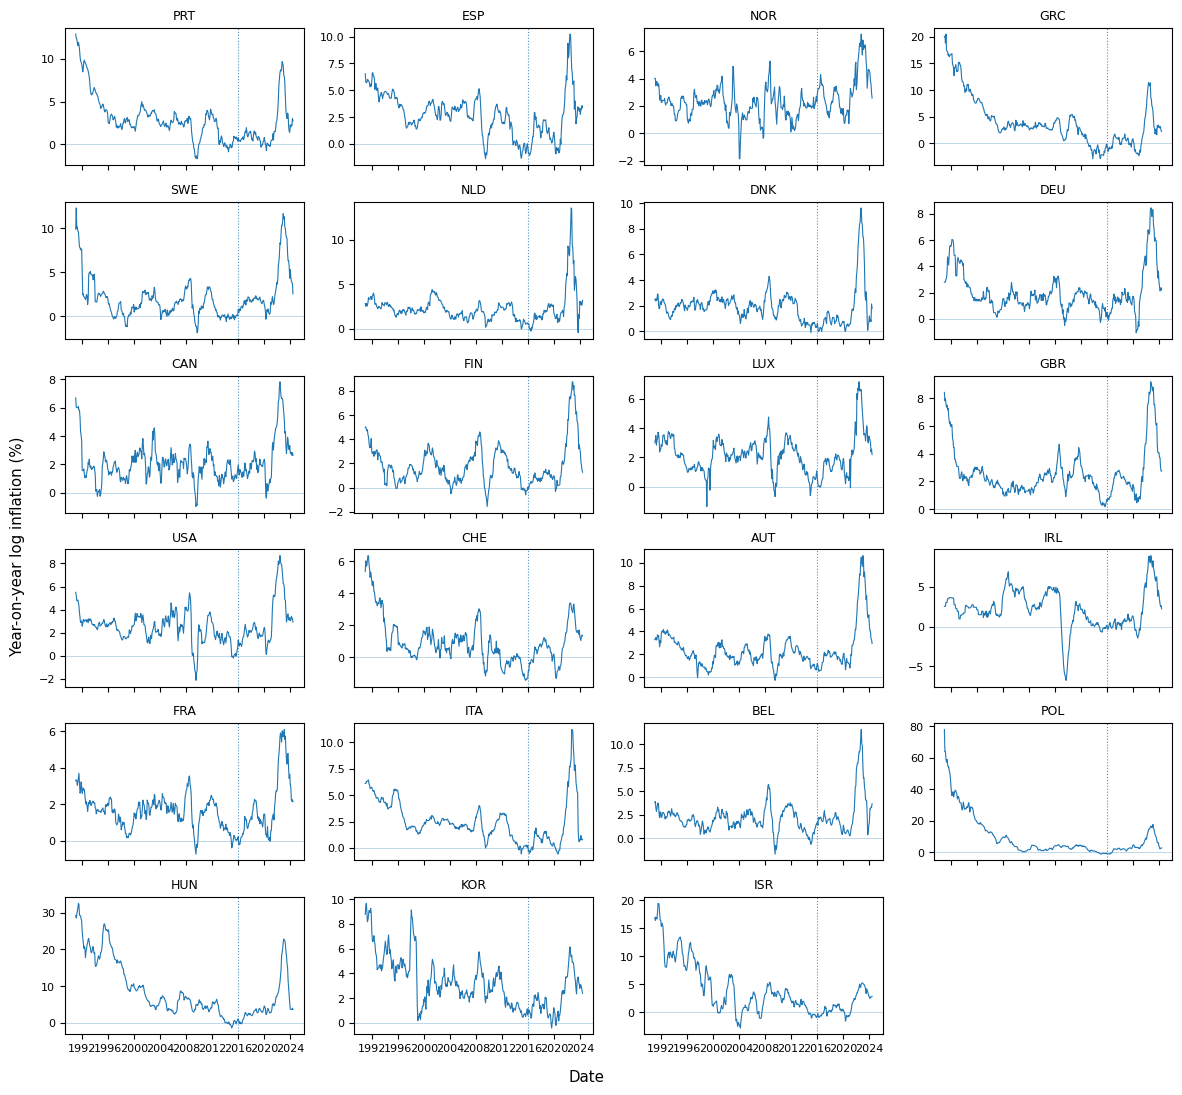

In [87]:
# Small-multiple check of every retained inflation series.
fig, axes = plt.subplots(6, 4, figsize=(12, 11), sharex=True)
axes = axes.ravel()

for ax, country in zip(axes, COUNTRIES):
    ax.plot(inflation.index, inflation[country], linewidth=0.8)
    ax.axvline(SPLIT_DATE, linestyle=":", linewidth=0.8, alpha=0.8)
    ax.axhline(0, linewidth=0.5, alpha=0.4)
    ax.set_title(country)

for ax in axes[len(COUNTRIES):]:
    ax.set_visible(False)

fig.supxlabel("Date")
fig.supylabel("Year-on-year log inflation (%)")
fig.tight_layout()
plt.show()

## Observed networks

In [90]:
gravity = pd.read_csv(GRAVITY_RAW)

geo = gravity[
    (gravity["year"] == 2015)
    & gravity["iso3_o"].isin(COUNTRIES)
    & gravity["iso3_d"].isin(COUNTRIES)
][["iso3_o", "iso3_d", "distw_harmonic"]].copy()

geo = geo.dropna(subset=["distw_harmonic"])
geo = geo.groupby(["iso3_o", "iso3_d"])["distw_harmonic"].mean().reset_index()

D = geo.pivot(index="iso3_o", columns="iso3_d", values="distw_harmonic")
D = D.reindex(index=COUNTRIES, columns=COUNTRIES)

W_geo = 1 / D
for country in COUNTRIES:
    W_geo.loc[country, country] = 0
W_geo = W_geo.div(W_geo.sum(axis=1), axis=0)

verify_or_save(W_geo, W_GEO_OUT)

/var/folders/d5/bt4mpp9n3gngv4q0rms4ylwm0000gn/T/ipykernel_44415/1127864738.py:1: DtypeWarning: Columns (0: empire) have mixed types. Specify dtype option on import or set low_memory=False.
  gravity = pd.read_csv(GRAVITY_RAW)


verified existing data/CEPII/W_geo.csv


In [91]:
comtrade = pd.read_csv(COMTRADE_RAW, index_col=False)
trade = comtrade[
    comtrade["refYear"].isin([2013, 2014, 2015])
    & comtrade["reporterISO"].isin(COUNTRIES)
    & comtrade["partnerISO"].isin(COUNTRIES)
    & (comtrade["cmdCode"] == "TOTAL")
].copy()
trade["primaryValue"] = pd.to_numeric(trade["primaryValue"], errors="coerce")


def build_trade_matrix(data, flow):
    """Return the row-normalised reporter-to-partner matrix for one trade flow."""
    avg = (
        data[data["flowDesc"] == flow]
        .groupby(["reporterISO", "partnerISO"])["primaryValue"]
        .mean()
        .reset_index()
    )
    W = avg.pivot(index="reporterISO", columns="partnerISO", values="primaryValue")
    W = W.reindex(index=COUNTRIES, columns=COUNTRIES).fillna(0)
    for country in COUNTRIES:
        W.loc[country, country] = 0
    return W.div(W.sum(axis=1), axis=0)


# Export rows are reporters/exporters and columns are destinations.
# Import rows are reporters/importers and columns are source partners.
W_ex = build_trade_matrix(trade, "Export")
W_im = build_trade_matrix(trade, "Import")

verify_or_save(W_ex, W_EX_OUT)
verify_or_save(W_im, W_IM_OUT)

verified existing data/Comtrade/W_ex.csv
verified existing data/Comtrade/W_im.csv


In [137]:
def check_network(name, W):
    """Check the properties required by the downstream GNAR code."""
    values = W.to_numpy(dtype=float)
    off_diag = values[~np.eye(N, dtype=bool)]
    assert W.shape == (N, N)
    assert np.isfinite(values).all()
    assert (values >= 0).all()
    assert np.allclose(np.diag(values), 0.0)
    assert np.allclose(values.sum(axis=1), 1.0)
    assert (off_diag > 0).all()
    print(f"{name:10s} complete off-diagonal support; max weight={values.max():.5f}")

NETS = [("geographic", W_geo), ("export", W_ex), ("import", W_im)]

for name, W in NETS:
    check_network(name, W)

geographic complete off-diagonal support; max weight=0.27928
export     complete off-diagonal support; max weight=0.89990
import     complete off-diagonal support; max weight=0.79216


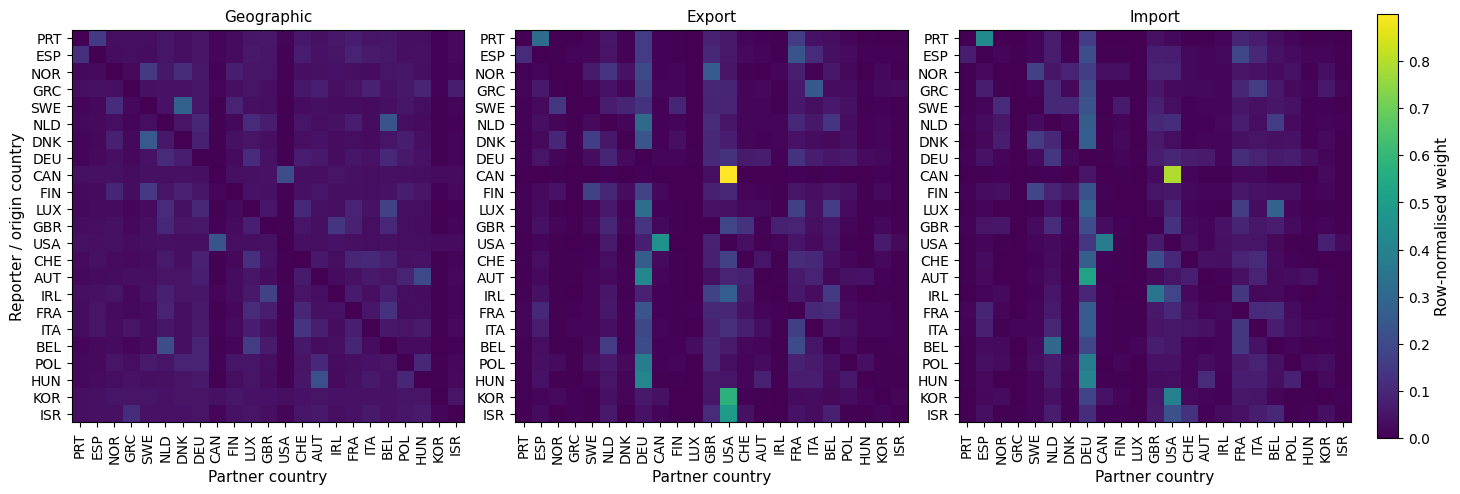

In [93]:
# Compact visual check of the three final weight matrices on a common scale.
matrices = [("Geographic", W_geo), ("Export", W_ex), ("Import", W_im)]
vmax = max(W.to_numpy().max() for _, W in matrices)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), constrained_layout=True)
for ax, (label, W) in zip(axes, matrices):
    im = ax.imshow(W.to_numpy(), vmin=0, vmax=vmax, aspect="equal")
    ax.set_title(label)
    ax.set_xticks(range(N), COUNTRIES, rotation=90)
    ax.set_yticks(range(N), COUNTRIES)
    ax.set_xlabel("Partner country")
axes[0].set_ylabel("Reporter / origin country")

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Row-normalised weight")
plt.show()